# D-01 — A Máquina de Turing

<div style="border-left: 2px solid #6b7280; padding: 0.5em 1em 0.5em 1.1em; margin: 0.8em 0 1.2em 0; background: rgba(107, 114, 128, 0.05); border-radius: 0 3px 3px 0;">
  <span style="font-size: 0.65em; font-weight: 700; letter-spacing: 0.13em; text-transform: uppercase; color: #9ca3af;">ETIMOLOGIA </span><br>
  
  <span style="font-size: 0.88em; line-height: 1.65;"><b>Computabilidade</b> vem do latim <i>computare</i>: <i>com-</i> (“junto”) + <i>putare</i> (“calcular”, “avaliar”). A ideia original é a de realizar um cálculo por meio de um procedimento. <b>Em termos gerais</b>, “computabilidade” trata de quais problemas admitem um procedimento finito e bem definido que produz uma resposta.</span><br>
  
  <span style="font-size: 0.88em; line-height: 1.65;"><b>Complexidade</b> vem do latim <i>complexus</i>: <i>com-</i> (“junto”) + <i>plectere</i> (“entrelaçar”, “trançar”). A ideia original é a de algo entrelaçado, difícil de separar. <b>Em termos gerais</b>, “complexidade” descreve o custo necessário para resolver um problema — como esse custo cresce à medida que o tamanho da entrada aumenta.</span>
</div>

## Introdução

A computação quântica só faz sentido em relação à computação clássica. Para entender o que ela expande — e o que ela não expande —, é preciso ter um modelo preciso do que um computador clássico pode fazer. A `máquina de Turing` é esse modelo: abstrata o suficiente para não depender de hardware específico, precisa o suficiente para definir o que é computável e o que não é.

Este notebook constrói esse modelo e introduz a teoria de complexidade que permite comparar algoritmos clássicos e quânticos.

## 1. A máquina de Turing

*Esqueleto — expandir aqui*

Ideias centrais a desenvolver:

- Uma máquina de Turing consiste em: uma `fita infinita` de células (memória), um `cabeçote` que lê e escreve, um conjunto finito de `estados internos`, e uma `função de transição` que diz o que fazer a cada passo.
- A função de transição: dado o estado atual e o símbolo lido, especifica o próximo estado, o símbolo a escrever, e a direção do movimento (esquerda/direita).
- `Tese de Church-Turing`: qualquer função computável por algum procedimento mecânico é computável por uma máquina de Turing. Não é um teorema — é uma tese sobre o que significa "computar".
- `Universalidade`: existe uma máquina de Turing universal que pode simular qualquer outra máquina de Turing. Isso é o fundamento do software: um programa é uma descrição de uma máquina de Turing.

In [1]:
# ── Simulação mínima de uma máquina de Turing ────────────────────────────────
# Exemplo: máquina que inverte todos os bits de uma fita binária
# Estados: q0 (em operação), q_halt (parada)
# Símbolos: 0, 1, B (branco)

def turing_inversor(fita_inicial):
    fita = list(fita_inicial) + ['B'] * 10
    estado = 'q0'
    pos = 0
    historico = []

    # Função de transição: (estado, símbolo) → (próximo estado, escreve, move)
    transicao = {
        ('q0', '0'): ('q0', '1', +1),
        ('q0', '1'): ('q0', '0', +1),
        ('q0', 'B'): ('q_halt', 'B', 0),
    }

    while estado != 'q_halt':
        simbolo = fita[pos]
        historico.append((estado, pos, ''.join(fita[:len(fita_inicial)])))
        prox_estado, escreve, move = transicao[(estado, simbolo)]
        fita[pos] = escreve
        pos += move
        estado = prox_estado

    return ''.join(fita[:len(fita_inicial)]), historico

entrada = '110100'
saida, historico = turing_inversor(entrada)

print(f'Entrada:  {entrada}')
print(f'Saída:    {saida}')
print()
print('Passos de execução:')
for estado, pos, fita in historico:
    print(f'  estado={estado}  pos={pos}  fita={fita}')

Entrada:  110100
Saída:    001011

Passos de execução:
  estado=q0  pos=0  fita=110100
  estado=q0  pos=1  fita=010100
  estado=q0  pos=2  fita=000100
  estado=q0  pos=3  fita=001100
  estado=q0  pos=4  fita=001000
  estado=q0  pos=5  fita=001010
  estado=q0  pos=6  fita=001011


## 2. O que não é computável


*Esqueleto — expandir aqui*

Ideias centrais a desenvolver:

- **`Problema da parada` (Turing, 1936):** não existe máquina de Turing que, dada qualquer máquina $M$ e entrada $x$, determine se $M$ para com $x$. Prova por diagonalização.
- Consequência: há perguntas bem formuladas que nenhum algoritmo pode responder. A computabilidade tem limites absolutos, não apenas práticos.
- Não confundir com complexidade: um problema pode ser computável mas impraticável (muito lento).

## 3. Complexidade computacional

*Esqueleto — expandir aqui*

Ideias centrais a desenvolver:

- A teoria de complexidade classifica problemas pelo custo de resolvê-los em função do tamanho da entrada $n$.
- **`Classe P`**: problemas resolvíveis em tempo polinomial $O(n^k)$ — considerados tratáveis.
- **`Classe NP`**: problemas onde uma solução pode ser verificada em tempo polinomial. A questão P vs NP é o maior problema aberto da ciência da computação.
- **`Classe BPP`**: problemas resolvíveis em tempo polinomial por um algoritmo probabilístico com erro limitado. É a classe dos problemas "classicamente eficientes com aleatoriedade".
- **`Classe BQP`**: a versão quântica de BPP — problemas resolvíveis em tempo polinomial por um computador quântico com erro limitado.
- Relações: $P \subseteq BPP \subseteq BQP$ (provavelmente). Fatoração está em BQP mas não se sabe se está em P ou BPP.
- Mostrar: diagrama das classes de complexidade e onde algoritmos quânticos conhecidos se encaixam.

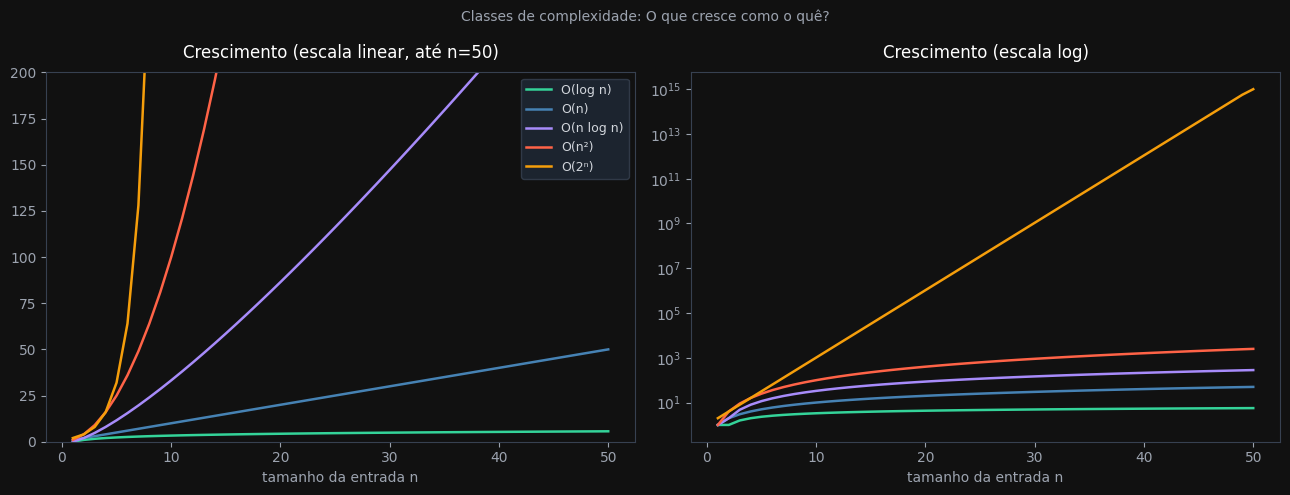

Polinomial vs. exponencial: a diferença entre tratável e intratável
2^50 = 1,125,899,906,842,624 operações   |   50² = 2500 operações


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ── Crescimento de complexidade: visual intuitivo ────────────────────────────
n = np.arange(1, 51)

complexidades = {
    'O(log n)':   np.log2(n),
    'O(n)':       n,
    'O(n log n)': n * np.log2(n),
    'O(n²)':      n**2,
    'O(2ⁿ)':      np.minimum(2.0**n, 1e15),
}
colors_c = ['#34d399', 'steelblue', '#a78bfa', 'tomato', '#f59e0b']

fig, axes = plt.subplots(1, 2, figsize=(13, 5), facecolor='#111')
fig.patch.set_facecolor('#111')

for ax in axes:
    ax.set_facecolor('#111')
    ax.tick_params(colors='#9ca3af')
    for spine in ax.spines.values():
        spine.set_edgecolor('#374151')

for (nome, vals), color in zip(complexidades.items(), colors_c):
    axes[0].plot(n, vals, color=color, lw=1.8, label=nome)
    axes[1].semilogy(n, np.maximum(vals, 1), color=color, lw=1.8, label=nome)

axes[0].set_ylim(0, 200)
axes[0].set_title('Crescimento (escala linear, até n=50)', color='white', pad=10)
axes[0].set_xlabel('tamanho da entrada n', color='#9ca3af')
axes[0].legend(fontsize=9, labelcolor='#d1d5db', facecolor='#1f2937', edgecolor='#374151')

axes[1].set_title('Crescimento (escala log)', color='white', pad=10)
axes[1].set_xlabel('tamanho da entrada n', color='#9ca3af')

plt.suptitle('Classes de complexidade: O que cresce como o quê?', color='#9ca3af', fontsize=10)
plt.tight_layout()
plt.show()

print('Polinomial vs. exponencial: a diferença entre tratável e intratável')
print(f'2^50 = {2**50:,.0f} operações   |   50² = {50**2} operações')

## 4. A máquina de Turing quântica

*Esqueleto — expandir aqui*

Ideias centrais a desenvolver:

- Deutsch (1985) generaliza a máquina de Turing para o caso quântico: a fita e os estados internos estão em superposição, e a função de transição é uma `transformação unitária`.
- A `máquina de Turing quântica` é o modelo teórico; o `circuito quântico` é o modelo prático que usamos.
- `Equivalência`: circuitos quânticos polinomiais e máquinas de Turing quânticas de tempo polinomial são equivalentes em poder computacional.
- O que muda: a máquina quântica pode entrar em superposição de configurações e explorá-las em paralelo — mas só pode ler um resultado de cada vez (medição).
- A vantagem quântica não é "testar tudo de uma vez e ler tudo"; é usar `interferência` para concentrar a probabilidade na resposta correta antes de medir.

## Por que isso importa para algoritmos quânticos

A teoria de complexidade dá o vocabulário para comparar computação clássica e quântica:

- Shor mostrou que fatoração está em **BQP** — resolvível eficientemente em computador quântico. Não se sabe se está em P ou BPP.
- Grover mostrou um speedup quadrático para busca — qualquer problema em NP pode usar Grover como subroutine, mas o speedup é quadrático, não exponencial.
- `Oráculo vs. estrutura`: muitos speedups quânticos são demonstrados no modelo de oráculo. Quando o problema tem estrutura (como periodicidade no caso de Shor), o speedup é real. Quando não tem, Grover é o melhor possível.
- A questão em aberto: BQP ⊃ BPP? Isto é, existe problema classicamente intratável mas quanticamente tratável fora do modelo de oráculo? Shor sugere que sim — mas a prova rigorosa ainda não existe.

<a href="../digressoes/D-07.ipynb" style="font-size: 0.82em; color: #6b7280; text-decoration: none; border-bottom: 1px dashed #6b7280; white-space: nowrap;">↳ D-07 — A História da Computação Quântica</a>